### ASSIGNMENT No: 7 

Title: Write a python program to show Back Propagation Network for XOR function with Binary Input and Output 

Problem Statement:  Implement to show Back Propagation Network for XOR function with Binary Input and Output

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

In [3]:
class SimpleNN:
    def __init__(self, lr=0.5, epochs=10000):
        self.lr = lr
        self.epochs = epochs
        
        np.random.seed(1)
        
        # Weights
        self.w1 = np.random.rand()
        self.w2 = np.random.rand()
        self.w3 = np.random.rand()
        self.w4 = np.random.rand()
        self.w5 = np.random.rand()
        self.w6 = np.random.rand()
        
        # Bias
        self.b1 = np.random.rand()
        self.b2 = np.random.rand()
        
        self.losses = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, x1, x2):
        h1 = self.sigmoid(x1*self.w1 + x2*self.w2 + self.b1)
        h2 = self.sigmoid(x1*self.w3 + x2*self.w4 + self.b1)
        
        o = self.sigmoid(h1*self.w5 + h2*self.w6 + self.b2)
        
        return h1, h2, o

    def fit(self, X, y):
        for epoch in range(self.epochs):
            total_loss = 0
            
            for i in range(len(X)):
                x1, x2 = X[i]
                target = y[i]
                
                h1, h2, output = self.forward(x1, x2)
                
                error = target - output
                total_loss += error**2
                
                d_output = error * self.sigmoid_derivative(output)
                
                d_h1 = d_output * self.w5 * self.sigmoid_derivative(h1)
                d_h2 = d_output * self.w6 * self.sigmoid_derivative(h2)
                
                # Update weights
                self.w5 += self.lr * d_output * h1
                self.w6 += self.lr * d_output * h2
                self.b2 += self.lr * d_output
                
                self.w1 += self.lr * d_h1 * x1
                self.w2 += self.lr * d_h1 * x2
                
                self.w3 += self.lr * d_h2 * x1
                self.w4 += self.lr * d_h2 * x2
                
                self.b1 += self.lr * (d_h1 + d_h2)
            
            self.losses.append(total_loss)

    def predict(self, X):
        results = []
        for i in range(len(X)):
            x1, x2 = X[i]
            _, _, output = self.forward(x1, x2)
            results.append(round(output))
        return results

    def plot_loss(self):
        plt.plot(self.losses)
        plt.title("Loss vs Epoch")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.show()

In [4]:
model = SimpleNN(lr=0.5, epochs=10000)
model.fit(X, y)

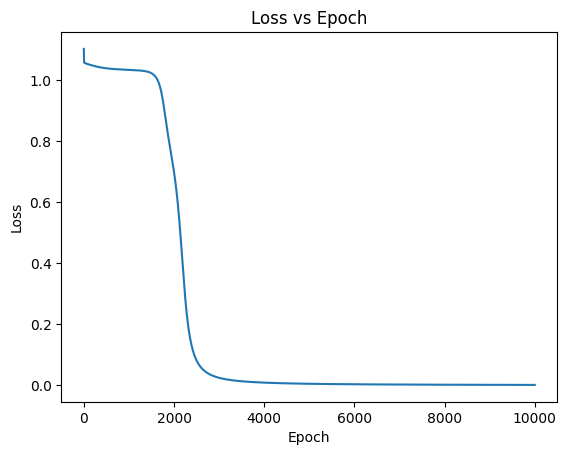

In [5]:
model.plot_loss()

In [6]:
print("Final Predictions:\n")

preds = model.predict(X)

for i in range(len(X)):
    print(X[i], "->", preds[i])

Final Predictions:

[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0
